# Conditional Variational Auto-Encoder (CVAE) on Fashion-MNIST

### COMP8221 — Advanced Machine Learning · Assignment 1 · Option 2: Variational Auto-Encoder

| Item | Details |
|---|---|
| **Student Name** | *Nhat Huy Nguyen* |
| **Student ID** | *60770481* |
| **Model** | Conditional VAE (CVAE), implemented from scratch |
| **Dataset** | Fashion-MNIST (28×28 grayscale, 10 classes) |
| **Framework** | PyTorch (CUDA / Apple-Silicon MPS / CPU) |
| **File name** | `2026S2_COMP8221_Assignment_1_60770481_NhatHuyNguyen.ipynb` |


## How to run this notebook

1. Install the dependencies (Python ≥ 3.10):
   ```bash
   pip install torch torchvision matplotlib numpy pandas scikit-learn
   ```
2. Open the notebook (VS Code / Jupyter) and select **Run All**. Fashion-MNIST (~30 MB) is downloaded automatically to `./data`.
3. The device is chosen automatically: CUDA → Apple MPS → CPU.
4. **Training pipeline:** Sections 5–6. Trained weights are saved to `./checkpoints/`. If a checkpoint already exists, training is skipped and the weights are loaded (set `CONFIG["retrain"] = True` to force retraining).
5. **Inference pipeline:** Sections 7–8 only load the saved checkpoints, so after one full run they can be re-run on their own.
6. For a fast smoke test (2 epochs on a data subset), set `QUICK_RUN = True` in Section 2. **Use `QUICK_RUN = False` for the submitted results.**

All figures are also saved to `./results/`

## 1. Introduction

A Variational Auto-Encoder (VAE; Kingma & Welling, 2014) is a latent-variable generative model $p_\theta(x, z) = p_\theta(x \mid z)\,p(z)$ trained by maximising the Evidence Lower Bound (ELBO) with an amortised approximate posterior $q_\phi(z \mid x)$. A standard VAE gives no control over *what* is generated: to obtain an image of a particular class one has to search the latent space.

The **Conditional VAE (CVAE)** of Sohn, Lee & Yan (2015) conditions every distribution of the model on an observed variable $y$ (here, the class label). The encoder becomes $q_\phi(z \mid x, y)$ and the decoder becomes $p_\theta(x \mid z, y)$. Because the label is supplied to the decoder directly, the latent code $z$ no longer needs to store class identity and can be used for the remaining *within-class* variation (shape, thickness, texture, orientation). At generation time we choose $y$ and sample $z \sim p(z)$, which gives class-controlled generation.

This makes CVAE a valid VAE variant for this assignment: it changes both the **architecture** (label-conditioned encoder and decoder) and the **objective** (a conditional ELBO), which matches the criterion in FAQ 5 of the assignment brief.

**Research questions explored in this notebook**

1. Does conditioning on the label give reliable class control? (measured with an independent classifier, Sections 6.5–6.6)
2. How does the size of the latent space ($d_z \in \{2, 16, 32\}$) trade reconstruction quality against the KL term? (Sections 6.3–6.4)
3. Does the latent space of a CVAE encode *style* rather than *class*? (Section 6.7 and Sections 7.4–7.6)

**Notebook structure.** Section 2: setup. Section 3: model. Section 4: objective. Section 5: data. Section 6: training and **quantitative** evaluation. Section 7: **qualitative** analysis and visualisation. Section 8: discussion. Section 9: conclusion. Following the brief, quantitative results (numbers, curves) and qualitative results (images, latent plots) are kept in separate sections.

## 2. Setup and Configuration

### 2.1 Imports, reproducibility and device

In [1]:
import os, json, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 42
def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed()

# ------------------------------------------------------------
# Device: CUDA -> Apple Silicon (MPS) -> CPU
# Note: results on MPS/CUDA are not guaranteed to be bit-identical
# across runs even with a fixed seed, but they are statistically stable.
# ------------------------------------------------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"PyTorch {torch.__version__} | device: {device}")

PyTorch 2.10.0 | device: mps


### 2.2 Experimental configuration

All hyperparameters are kept in one dictionary so the experiment is easy to inspect and reproduce.

In [2]:
# Set QUICK_RUN = True only for a fast smoke test. Use False for the final results.
QUICK_RUN = os.environ.get("CVAE_QUICK_RUN", "0") == "1"

CONFIG = {
    # Data
    "data_dir": "./data",
    "val_size": 5000,             # held out from the 60k training images
    "batch_size": 128,
    "hflip_p": 0.5,               # horizontal-flip augmentation probability
    # Model
    "num_classes": 10,
    "hidden_dim": 256,
    "latent_dims": [2, 16, 32],   # latent-dimension study (Section 6.3)
    "main_latent_dim": 16,        # model used for most visualisations
    # Optimisation
    "lr": 1e-3,
    "epochs": 30,
    # Evaluation
    "clf_epochs": 5,              # epochs for the evaluation classifier
    "gen_per_class": 1000,        # generated samples per class for label accuracy
    # I/O
    "checkpoint_dir": "./checkpoints",
    "results_dir": "./results",
    "retrain": False,             # True = ignore saved checkpoints
}
if QUICK_RUN:
    CONFIG.update({"epochs": 2, "clf_epochs": 1, "gen_per_class": 100,
                   "checkpoint_dir": "./checkpoints_quick", "results_dir": "./results_quick"})

os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
os.makedirs(CONFIG["results_dir"], exist_ok=True)
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

def save_fig(name):
    plt.savefig(os.path.join(CONFIG["results_dir"], name), dpi=150, bbox_inches="tight")

print(json.dumps(CONFIG, indent=2), "\nQUICK_RUN =", QUICK_RUN)

{
  "data_dir": "./data",
  "val_size": 5000,
  "batch_size": 128,
  "hflip_p": 0.5,
  "num_classes": 10,
  "hidden_dim": 256,
  "latent_dims": [
    2,
    16,
    32
  ],
  "main_latent_dim": 16,
  "lr": 0.001,
  "epochs": 30,
  "clf_epochs": 5,
  "gen_per_class": 1000,
  "checkpoint_dir": "./checkpoints",
  "results_dir": "./results",
  "retrain": false
} 
QUICK_RUN = False


## 3. Model Architecture — Conditional VAE (from scratch)

The model is built only from standard layers (`nn.Conv2d`, `nn.ConvTranspose2d`, `nn.Linear`). No generative library is used.

<table>
<tr>
<th style="width:50%; text-align:center;">Encoder q(z | x, y)</th>
<th style="width:50%; text-align:center;">Decoder p(x | z, y)</th>
</tr>

<tr>
<td>

<pre>
x (1 × 28 × 28)
        │
        ▼
Conv2d (4 × 4, stride=2, padding=1)
        │
        ▼
32 × 14 × 14
        │
        ▼
Conv2d (4 × 4, stride=2, padding=1)
        │
        ▼
64 × 7 × 7
        │
        ▼
Flatten → 3136
        │
        ├── concatenate one-hot y (10)
        │
        ▼
Linear (3146 → 256)
        │
      ReLU
        │
        ├──► Linear → μ
        │
        └──► Linear → log σ²
</pre>

</td>

<td>

<pre>
[z ; one-hot y]
        │
        ▼
Linear → 256
        │
        ▼
Linear → 3136
        │
        ▼
Reshape → 64 × 7 × 7
        │
        ▼
ConvTranspose2d
(4 × 4, stride=2, padding=1)
        │
        ▼
32 × 14 × 14
        │
        ▼
ConvTranspose2d
(4 × 4, stride=2, padding=1)
        │
        ▼
1 × 28 × 28 logits
        │
        ▼
Sigmoid → Bernoulli means
</pre>

</td>
</tr>
</table>


Design choices:

* **Strided convolutions** instead of pooling, so the down/up-sampling is learned. Kernel 4, stride 2, padding 1 halves (or doubles) the spatial size exactly (28 → 14 → 7).
* **The encoder predicts $\log\sigma^2$** instead of $\sigma$. This keeps the output unconstrained and makes the KL term numerically stable.
* **The decoder outputs logits**, and the loss uses `binary_cross_entropy_with_logits`. This is more stable than applying a sigmoid and then a log.

### 3.1 Label conditioning

The label is represented as a one-hot vector $y \in \{0,1\}^{10}$. In the encoder it is concatenated with the flattened convolutional features. In the decoder it is concatenated with $z$. **This is the variant-specific modification**: remove the two concatenations and the model collapses back to a standard VAE.

In [3]:
def one_hot(labels: torch.Tensor, num_classes: int = 10) -> torch.Tensor:
    # Integer labels (B,) -> float one-hot (B, num_classes).
    return F.one_hot(labels, num_classes).float()


class Encoder(nn.Module):
    # q_phi(z | x, y): outputs the mean and log-variance of a diagonal Gaussian.
    def __init__(self, latent_dim: int, num_classes: int = 10, hidden_dim: int = 256):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),   # 28 -> 14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 14 -> 7
            nn.ReLU(),
            nn.Flatten(),                                           # 64*7*7 = 3136
        )
        self.fc = nn.Sequential(nn.Linear(64 * 7 * 7 + num_classes, hidden_dim), nn.ReLU())
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x, y_onehot):
        h = self.conv(x)
        h = torch.cat([h, y_onehot], dim=1)        # <-- conditioning on y (CVAE)
        h = self.fc(h)
        return self.fc_mu(h), self.fc_logvar(h)


class Decoder(nn.Module):
    # p_theta(x | z, y): outputs Bernoulli logits for each of the 784 pixels.
    def __init__(self, latent_dim: int, num_classes: int = 10, hidden_dim: int = 256):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim + num_classes, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 64 * 7 * 7), nn.ReLU(),
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 7 -> 14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),   # 14 -> 28
        )

    def forward(self, z, y_onehot):
        h = self.fc(torch.cat([z, y_onehot], dim=1))  # <-- conditioning on y (CVAE)
        h = h.view(-1, 64, 7, 7)
        return self.deconv(h)                          # logits, shape (B, 1, 28, 28)

### 3.2 Reparameterisation trick and the full CVAE

Sampling $z \sim \mathcal{N}(\mu, \sigma^2 I)$ is not differentiable with respect to $\mu$ and $\sigma$. The reparameterisation trick (Kingma & Welling, 2014) rewrites the sample as a deterministic function of the parameters plus independent noise:

$$z = \mu + \sigma \odot \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, I), \qquad \sigma = \exp\!\left(\tfrac{1}{2}\log\sigma^2\right).$$

Gradients can now flow through $\mu$ and $\sigma$ into the encoder. At evaluation time we also use the posterior mean $\mu$ as a deterministic encoding.

In [4]:
class CVAE(nn.Module):
    def __init__(self, latent_dim: int, num_classes: int = 10, hidden_dim: int = 256):
        super().__init__()
        self.latent_dim, self.num_classes = latent_dim, num_classes
        self.encoder = Encoder(latent_dim, num_classes, hidden_dim)
        self.decoder = Decoder(latent_dim, num_classes, hidden_dim)

    @staticmethod
    def reparameterize(mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x, labels):
        y = one_hot(labels, self.num_classes)
        mu, logvar = self.encoder(x, y)
        z = self.reparameterize(mu, logvar)
        logits = self.decoder(z, y)
        return logits, mu, logvar

    @torch.no_grad()
    def sample(self, labels, z=None):
        # Generate images for the given labels, with z ~ p(z) = N(0, I) unless z is given.
        if z is None:
            z = torch.randn(labels.size(0), self.latent_dim, device=labels.device)
        return torch.sigmoid(self.decoder(z, one_hot(labels, self.num_classes)))

    @torch.no_grad()
    def encode_mean(self, x, labels):
        mu, _ = self.encoder(x, one_hot(labels, self.num_classes))
        return mu

### 3.3 Sanity check

In [5]:
_m = CVAE(latent_dim=CONFIG["main_latent_dim"]).to(device)
_x = torch.rand(8, 1, 28, 28, device=device)
_y = torch.randint(0, 10, (8,), device=device)
_logits, _mu, _logvar = _m(_x, _y)
print("logits:", tuple(_logits.shape), "| mu:", tuple(_mu.shape), "| logvar:", tuple(_logvar.shape))
print("samples:", tuple(_m.sample(_y).shape))
print(f"Trainable parameters (d_z={CONFIG['main_latent_dim']}): "
      f"{sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
assert _logits.shape == _x.shape
del _m, _x, _y, _logits, _mu, _logvar

logits: (8, 1, 28, 28) | mu: (8, 16) | logvar: (8, 16)
samples: (8, 1, 28, 28)
Trainable parameters (d_z=16): 1,693,409


## 4. Objective — Conditional ELBO

For one data point $(x, y)$, the CVAE maximises the conditional ELBO (Sohn et al., 2015):

$$\log p_\theta(x \mid y) \;\ge\; \mathcal{L}(x, y) = \underbrace{\mathbb{E}_{q_\phi(z\mid x,y)}\big[\log p_\theta(x \mid z, y)\big]}_{\text{reconstruction}} \;-\; \underbrace{D_{\mathrm{KL}}\big(q_\phi(z \mid x, y)\,\|\,p(z)\big)}_{\text{regularisation}}.$$

Sohn et al. also allow a learned conditional prior. For class-conditional image generation, the common simplification is to keep the prior fixed at $p(z) = \mathcal{N}(0, I)$, independent of $y$. That is the choice made here, because it lets us sample new images simply by drawing $z \sim \mathcal{N}(0, I)$ for any chosen label.

**Reconstruction term.** Each pixel is modelled as a Bernoulli variable with mean $\hat{x}_i = \mathrm{sigmoid}(\text{logit}_i)$, so

$$-\log p_\theta(x \mid z, y) = -\sum_{i=1}^{784}\big[x_i \log \hat{x}_i + (1-x_i)\log(1-\hat{x}_i)\big],$$

which is the binary cross-entropy summed over pixels. The expectation is estimated with a single Monte-Carlo sample of $z$ per data point (Kingma & Welling, 2014).

**KL term.** For a diagonal Gaussian posterior and a standard normal prior, the KL divergence has a closed form:

$$D_{\mathrm{KL}} = -\tfrac{1}{2}\sum_{j=1}^{d_z}\big(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\big).$$

**Scaling across dimensions.** Both terms are **summed** over their dimensions (784 pixels, $d_z$ latent units) and then **averaged over the batch**. This keeps the relative weight of the two terms exactly as in the ELBO. If the reconstruction were averaged over pixels while the KL was summed, the KL would be over-weighted by a factor of 784, which would silently turn the model into a β-VAE-like objective (β-VAE is excluded by the brief). No β weight is used here: the objective is the exact negative conditional ELBO.

**Note on the Bernoulli likelihood.** Fashion-MNIST pixels are grey levels in $[0,1]$, not binary values. Using BCE on continuous targets is common practice, but strictly speaking it is not a normalised likelihood for continuous data (Loaiza-Ganem & Cunningham, 2019). The reported loss values are therefore best read as a training objective and a relative measure, not as exact log-likelihoods.

In [6]:
def cvae_loss(logits, x, mu, logvar):
    # Negative conditional ELBO, averaged over the batch.
    # Returns (total, reconstruction, kl); all are per-example averages.
    batch_size = x.size(0)
    recon = F.binary_cross_entropy_with_logits(logits, x, reduction="sum") / batch_size
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / batch_size
    return recon + kl, recon, kl

# Quick numerical check of the KL formula against torch.distributions
_mu, _lv = torch.randn(4, 3), torch.randn(4, 3)
_q = torch.distributions.Normal(_mu, torch.exp(0.5 * _lv))
_p = torch.distributions.Normal(torch.zeros_like(_mu), torch.ones_like(_mu))
_ref = torch.distributions.kl_divergence(_q, _p).sum() / 4
_ours = -0.5 * torch.sum(1 + _lv - _mu.pow(2) - _lv.exp()) / 4
print(f"closed-form KL = {_ours:.6f} | torch.distributions KL = {_ref:.6f}")
assert torch.allclose(_ours, _ref, atol=1e-5)

closed-form KL = 1.815896 | torch.distributions KL = 1.815896


## 5. Dataset and Preprocessing

### 5.1 Dataset choice: Fashion-MNIST

Fashion-MNIST (Xiao, Rasul & Vollgraf, 2017) contains 70,000 grayscale images of Zalando fashion products at 28×28 resolution: 60,000 for training and 10,000 for testing, in 10 balanced classes. It was designed as a drop-in replacement for MNIST that is harder to model.

Reasons for choosing it:

1. **Labels are required.** A CVAE conditions on $y$, so the dataset must be labelled. Fashion-MNIST gives 10 clean, balanced classes.
2. **Meaningful within-class variation.** Items in the same class vary in shape, width, sleeve length, texture and brightness. This is exactly the *style* information the CVAE latent space should capture, so the latent-space analysis in Section 7 has something to show.
3. **Harder than MNIST, but still feasible.** Its greater visual complexity makes the qualitative analysis (blurriness, class confusion) more informative, while the small image size allows several full training runs on a laptop GPU.
4. **Fits the likelihood.** The images are single-channel with pixel values that map naturally to $[0,1]$, matching the Bernoulli decoder (Section 5.2).

### 5.2 Preprocessing pipeline

**Normalisation → reconstruction loss.** `ToTensor()` maps uint8 pixels $\{0,\dots,255\}$ to floats in $[0,1]$ by dividing by 255. We deliberately do **not** standardise to zero mean or rescale to $[-1,1]$. The decoder outputs Bernoulli means through a sigmoid, and BCE requires targets in $[0,1]$. Standardised targets would fall outside this range and make the loss invalid.

**Augmentation.** Only `RandomHorizontalFlip(p=0.5)` is used, and only on the training split. A mirrored shirt, bag or shoe is still a valid member of the same class, so the flip adds variation without changing the label. This matters for a CVAE, because an augmentation that changed the class would corrupt the conditioning signal. For contrast, flipping MNIST digits would be wrong: a flipped digit can become another symbol. Rotations and large crops were avoided because Fashion-MNIST items are centred and upright. Changing the orientation or framing would teach the model a distribution that differs from the test data.

**Split.** 5,000 of the 60,000 training images are held out as a validation set, without augmentation. It is used for the validation-loss curves and for checkpoint selection. The official 10,000-image test set is used only for the final evaluation.

In [7]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=CONFIG["hflip_p"]),   # label-preserving augmentation
    transforms.ToTensor(),                                  # [0,255] -> [0,1]
])
eval_transform = transforms.ToTensor()                       # no augmentation

# Two views of the same 60k training images (with and without augmentation)
train_full_aug = datasets.FashionMNIST(CONFIG["data_dir"], train=True, download=True, transform=train_transform)
train_full_plain = datasets.FashionMNIST(CONFIG["data_dir"], train=True, download=True, transform=eval_transform)
test_set = datasets.FashionMNIST(CONFIG["data_dir"], train=False, download=True, transform=eval_transform)

# Fixed, seeded train/validation split
perm = torch.randperm(len(train_full_aug), generator=torch.Generator().manual_seed(SEED)).tolist()
val_idx, train_idx = perm[:CONFIG["val_size"]], perm[CONFIG["val_size"]:]
if QUICK_RUN:
    train_idx, val_idx = train_idx[:5000], val_idx[:1000]

train_set = Subset(train_full_aug, train_idx)
val_set = Subset(train_full_plain, val_idx)

# num_workers=0 is the most robust choice in notebooks on macOS; the dataset is small.
g = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_set, batch_size=CONFIG["batch_size"], shuffle=True, generator=g)
val_loader = DataLoader(val_set, batch_size=512, shuffle=False)
test_loader = DataLoader(test_set, batch_size=512, shuffle=False)

print(f"train: {len(train_set):,} | val: {len(val_set):,} | test: {len(test_set):,}")

train: 55,000 | val: 5,000 | test: 10,000


### 5.3 Verify the pipeline

batch: (128, 1, 28, 28), dtype=torch.float32, range=[0.00, 1.00], labels=(128,)


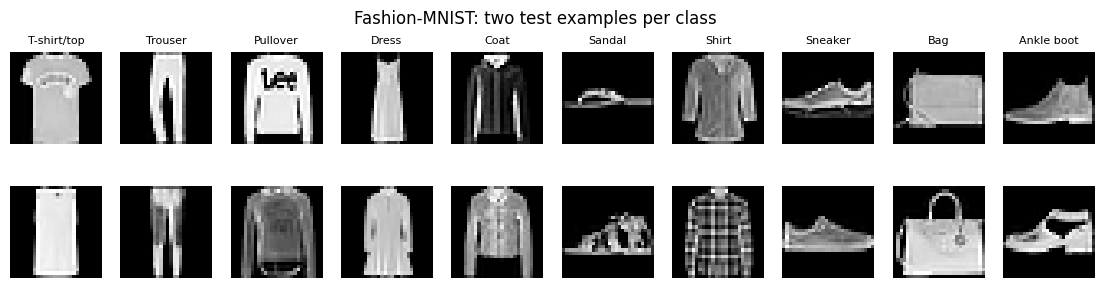

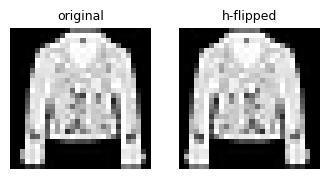

In [8]:
xb, yb = next(iter(train_loader))
print(f"batch: {tuple(xb.shape)}, dtype={xb.dtype}, range=[{xb.min():.2f}, {xb.max():.2f}], labels={tuple(yb.shape)}")
assert xb.min() >= 0 and xb.max() <= 1, "Targets must lie in [0,1] for BCE"

# Two examples per class from the test set
fig, axes = plt.subplots(2, 10, figsize=(14, 3.2))
targets = test_set.targets
for c in range(10):
    idx = (targets == c).nonzero().flatten()[:2]
    for r in range(2):
        axes[r, c].imshow(test_set[idx[r]][0].squeeze(), cmap="gray")
        axes[r, c].axis("off")
    axes[0, c].set_title(CLASS_NAMES[c], fontsize=8)
plt.suptitle("Fashion-MNIST: two test examples per class")
save_fig("data_examples.png"); plt.show()

# Effect of the augmentation on a single image
img = train_full_plain[train_idx[0]][0]
fig, ax = plt.subplots(1, 2, figsize=(4, 2.2))
ax[0].imshow(img.squeeze(), cmap="gray"); ax[0].set_title("original", fontsize=9)
ax[1].imshow(torch.flip(img, dims=[2]).squeeze(), cmap="gray"); ax[1].set_title("h-flipped", fontsize=9)
for a in ax: a.axis("off")
plt.show()

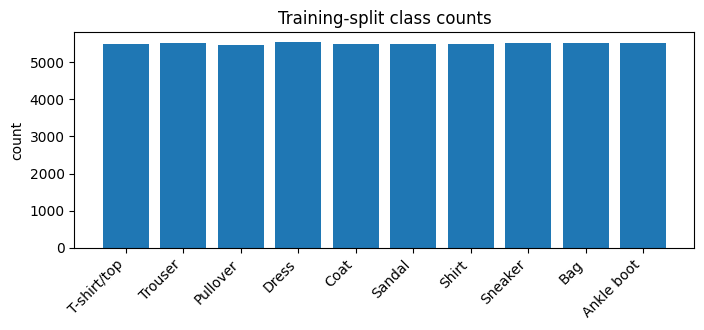

{'T-shirt/top': 5492, 'Trouser': 5507, 'Pullover': 5454, 'Dress': 5535, 'Coat': 5495, 'Sandal': 5486, 'Shirt': 5494, 'Sneaker': 5505, 'Bag': 5520, 'Ankle boot': 5512}


In [9]:
# Class balance of the training split
train_labels = train_full_plain.targets[train_idx]
counts = torch.bincount(train_labels, minlength=10).numpy()
plt.figure(figsize=(8, 2.8))
plt.bar(CLASS_NAMES, counts)
plt.xticks(rotation=45, ha="right"); plt.ylabel("count"); plt.title("Training-split class counts")
save_fig("class_balance.png"); plt.show()
print(dict(zip(CLASS_NAMES, counts.tolist())))

## 6. Training and Quantitative Evaluation

*This section contains only quantitative results: loss values, curves and metrics. Images are in Section 7.*

### 6.1 Training loop

* **Optimiser:** Adam (Kingma & Ba, 2015) with learning rate $10^{-3}$ and batch size 128. This is a standard setting for small convolutional VAEs.
* **Logging:** the reconstruction and KL terms are logged **separately** for the training set (averaged over the epoch) and for the validation set (at the end of each epoch).
* **Checkpointing:** the weights with the lowest validation negative ELBO are saved.
* **Latent-dimension study:** the same pipeline is trained for $d_z \in \{2, 16, 32\}$.

In [10]:
def run_epoch(model, loader, optimizer=None):
    # One pass over `loader`. Trains if an optimizer is given, otherwise evaluates.
    # Returns per-example averages of (total, recon, kl).
    train = optimizer is not None
    model.train(train)
    sums, n = np.zeros(3), 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits, mu, logvar = model(x, y)
            total, recon, kl = cvae_loss(logits, x, mu, logvar)
            if train:
                optimizer.zero_grad()
                total.backward()
                optimizer.step()
            b = x.size(0)
            sums += np.array([total.item(), recon.item(), kl.item()]) * b
            n += b
    return sums / n


def format_epoch(latent_dim, epoch, tr, va, dt):
    # One log line; tr and va are (total, recon, kl).
    return (f"[d_z={latent_dim:2d}] epoch {epoch:3d} | train -ELBO {tr[0]:7.2f} "
            f"(recon {tr[1]:7.2f}, KL {tr[2]:5.2f}) | val -ELBO {va[0]:7.2f} "
            f"(recon {va[1]:7.2f}, KL {va[2]:5.2f}) | {dt:5.1f}s")


def print_saved_log(latent_dim, history):
    # Re-print the per-epoch log stored in a checkpoint, so the training record
    # stays visible even when training is skipped.
    for e in range(len(history["train_total"])):
        tr = [history[f"train_{k}"][e] for k in ("total", "recon", "kl")]
        va = [history[f"val_{k}"][e] for k in ("total", "recon", "kl")]
        print(format_epoch(latent_dim, e + 1, tr, va, history["epoch_time"][e]))
    best = int(np.argmin(history["val_total"]))
    print(f"[d_z={latent_dim}] best validation -ELBO {history['val_total'][best]:.2f} at epoch {best + 1}")


def train_cvae(latent_dim):
    # Train one CVAE, or load it if a checkpoint exists. Returns (model, history).
    ckpt_path = os.path.join(CONFIG["checkpoint_dir"], f"cvae_z{latent_dim}.pt")
    model = CVAE(latent_dim, CONFIG["num_classes"], CONFIG["hidden_dim"]).to(device)

    if os.path.exists(ckpt_path) and not CONFIG["retrain"]:
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model_state"])
        print(f"[d_z={latent_dim}] loaded checkpoint (best epoch {ckpt['best_epoch']}); saved training log:")
        print_saved_log(latent_dim, ckpt["history"])
        return model, ckpt["history"]

    set_seed(SEED)
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])
    history = {k: [] for k in ["train_total", "train_recon", "train_kl",
                               "val_total", "val_recon", "val_kl", "epoch_time"]}
    best_val, best_epoch = float("inf"), -1

    for epoch in range(1, CONFIG["epochs"] + 1):
        t0 = time.time()
        tr = run_epoch(model, train_loader, optimizer)
        va = run_epoch(model, val_loader)
        dt = time.time() - t0
        for k, v in zip(["train_total", "train_recon", "train_kl"], tr): history[k].append(float(v))
        for k, v in zip(["val_total", "val_recon", "val_kl"], va): history[k].append(float(v))
        history["epoch_time"].append(dt)

        if va[0] < best_val:
            best_val, best_epoch = va[0], epoch
            torch.save({"model_state": model.state_dict(), "best_epoch": best_epoch,
                        "history": history, "config": CONFIG}, ckpt_path)
        print(format_epoch(latent_dim, epoch, tr, va, dt))

    # Reload the best weights and store the complete history
    ckpt = torch.load(ckpt_path, map_location=device)
    ckpt["history"] = history
    torch.save(ckpt, ckpt_path)
    model.load_state_dict(ckpt["model_state"])
    print(f"[d_z={latent_dim}] best validation -ELBO {best_val:.2f} at epoch {best_epoch}")
    return model, history


### 6.2 Launch training (skipped automatically if checkpoints exist)

In [11]:
models, histories = {}, {}
for d in CONFIG["latent_dims"]:
    models[d], histories[d] = train_cvae(d)

for d, h in histories.items():
    print(f"d_z={d:2d}: mean epoch time {np.mean(h['epoch_time']):.1f}s on {device}")

[d_z=2] loaded checkpoint (best epoch 30); saved training log:
[d_z= 2] epoch   1 | train -ELBO  283.99 (recon  279.09, KL  4.90) | val -ELBO  262.94 (recon  257.54, KL  5.40) |   6.6s
[d_z= 2] epoch   2 | train -ELBO  260.92 (recon  255.65, KL  5.26) | val -ELBO  260.77 (recon  255.36, KL  5.41) |   4.3s
[d_z= 2] epoch   3 | train -ELBO  258.63 (recon  253.36, KL  5.27) | val -ELBO  260.22 (recon  254.68, KL  5.54) |   4.2s
[d_z= 2] epoch   4 | train -ELBO  257.37 (recon  252.11, KL  5.26) | val -ELBO  258.18 (recon  252.83, KL  5.35) |   4.3s
[d_z= 2] epoch   5 | train -ELBO  256.54 (recon  251.28, KL  5.26) | val -ELBO  257.98 (recon  252.79, KL  5.19) |   4.2s
[d_z= 2] epoch   6 | train -ELBO  255.75 (recon  250.51, KL  5.24) | val -ELBO  256.70 (recon  251.52, KL  5.19) |   4.2s
[d_z= 2] epoch   7 | train -ELBO  255.22 (recon  249.97, KL  5.25) | val -ELBO  255.90 (recon  250.50, KL  5.40) |   4.3s
[d_z= 2] epoch   8 | train -ELBO  254.70 (recon  249.48, KL  5.22) | val -ELBO  256

### 6.3 Loss curves — reconstruction vs. KL (isolated)

As required by the brief, the two components of the objective are plotted separately, for both training and validation. The training values are averaged over each epoch while the weights are still changing, and augmentation is applied only to the training split. Small train/validation offsets are therefore expected and are not by themselves a sign of overfitting.

The KL panel uses a narrow y-axis range (roughly 10.6–12.2 nats), so the epoch-to-epoch movement of the validation KL looks larger than it is: it stays within about ±0.6 nats, against a total negative ELBO of about 236 nats. The reconstruction and total curves are still decreasing at epoch 30, so the models are not fully converged (the brief explicitly allows this).


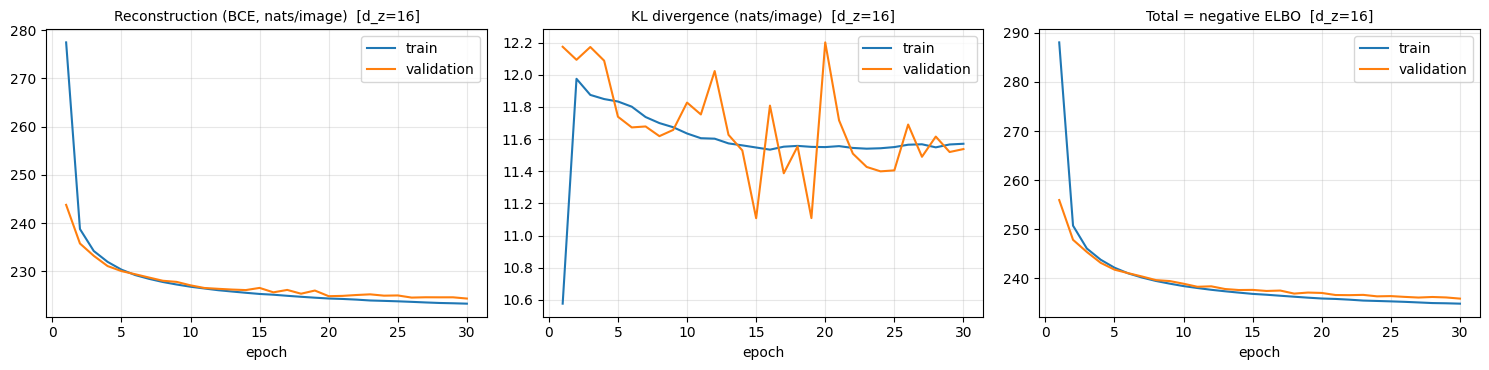

In [12]:
main = CONFIG["main_latent_dim"]
h = histories[main]
ep = np.arange(1, len(h["train_total"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, key, title in zip(axes, ["recon", "kl", "total"],
                          ["Reconstruction (BCE, nats/image)", "KL divergence (nats/image)", "Total = negative ELBO"]):
    ax.plot(ep, h[f"train_{key}"], label="train")
    ax.plot(ep, h[f"val_{key}"], label="validation")
    ax.set_title(f"{title}  [d_z={main}]", fontsize=10); ax.set_xlabel("epoch"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); save_fig("loss_curves_main.png"); plt.show()

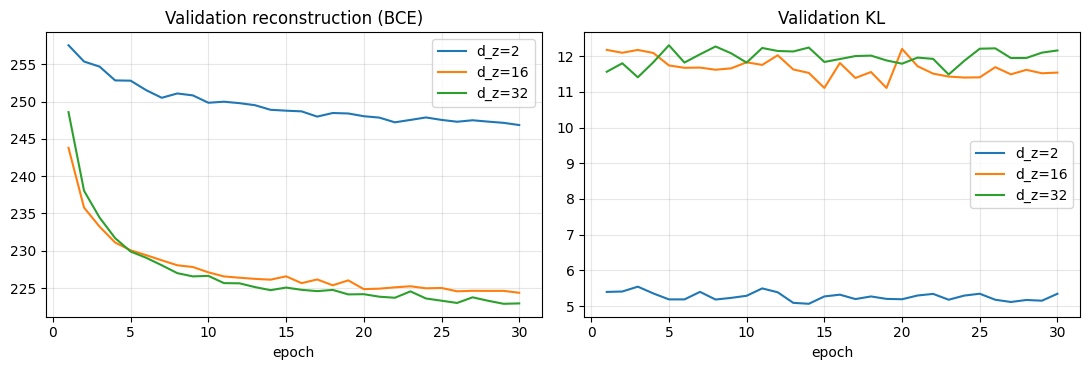

In [13]:
# Latent-dimension study: validation curves for every d_z
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for d, hh in histories.items():
    e = np.arange(1, len(hh["val_recon"]) + 1)
    axes[0].plot(e, hh["val_recon"], label=f"d_z={d}")
    axes[1].plot(e, hh["val_kl"], label=f"d_z={d}")
axes[0].set_title("Validation reconstruction (BCE)"); axes[1].set_title("Validation KL")
for a in axes: a.set_xlabel("epoch"); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); save_fig("loss_curves_latent_study.png"); plt.show()

### 6.4 Test-set metrics

For each latent size we report the following on the 10,000 unseen test images:

* **Negative ELBO** (= reconstruction + KL, in nats per image). This is an upper bound on $-\log p(x\mid y)$ under the Bernoulli model. See the caveat in Section 4.
* **Reconstruction BCE** and **KL** separately.
* **Reconstruction MSE per pixel**, between the test image and the decoded posterior mean ($z=\mu$). This is an intuitive, likelihood-free measure of reconstruction error.
* **Active units** (Burda, Grosse & Salakhutdinov, 2016): latent dimension $j$ counts as active if $\mathrm{Cov}_x\big(\mathbb{E}_{q(z\mid x,y)}[z_j]\big) > 0.01$. This shows how much of the latent space the model actually uses, which is relevant to the latent-dimension study.

The loss values are single-sample Monte-Carlo estimates, so they vary slightly between runs.

In [14]:
@torch.no_grad()
def evaluate_test(model):
    model.eval()
    set_seed(SEED)                     # fixed noise for the MC estimate
    total, recon, kl = run_epoch(model, test_loader)
    se, mus, n = 0.0, [], 0
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        mu = model.encode_mean(x, y)
        x_hat = model.sample(y, z=mu)  # deterministic reconstruction
        se += F.mse_loss(x_hat, x, reduction="sum").item()
        n += x.numel()
        mus.append(mu.cpu())
    mus = torch.cat(mus)
    active = int((mus.var(dim=0) > 0.01).sum())
    return {"neg_ELBO": total, "recon_BCE": recon, "KL": kl,
            "MSE_per_pixel": se / n, "active_units": f"{active}/{model.latent_dim}"}

results = pd.DataFrame({f"d_z={d}": evaluate_test(m) for d, m in models.items()}).T
results.to_csv(os.path.join(CONFIG["results_dir"], "test_metrics.csv"))
results

,neg_ELBO,recon_BCE,KL,MSE_per_pixel,active_units
d_z=2,253.019568,247.660079,5.359488,0.024433,2/2
d_z=16,237.144242,225.585406,11.558836,0.013783,7/16
d_z=32,236.475632,224.389326,12.086307,0.013081,8/32


### 6.5 Class-conditional accuracy of generated samples

Reconstruction metrics do not tell us whether **conditioning works**, which is the whole point of a CVAE. To measure it, we train a small, independent CNN classifier on the real training images (from scratch), check its accuracy on the real test set, and then classify samples generated by the CVAE ($z \sim \mathcal{N}(0,I)$). The **label-consistency accuracy** is the fraction of generated samples classified as the class they were conditioned on.

This is a supplementary, task-specific metric. It depends on the classifier, so it should be read relative to the classifier's accuracy on real test images. Disentanglement metrics such as the FactorVAE metric (Kim & Mnih, 2018) are **not applicable** here, because they require ground-truth generative factors (as in dSprites), and Fashion-MNIST only provides class labels.

The column `relative_to_real_acc` divides the label consistency by the classifier's accuracy on real test images, so 1.0 would mean the generated samples are as recognisable as real ones.


In [15]:
class SmallCNN(nn.Module):
    # Independent evaluation classifier; not part of the generative model.
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Dropout(0.3), nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Linear(128, 10))
    def forward(self, x): return self.net(x)

clf_path = os.path.join(CONFIG["checkpoint_dir"], "eval_classifier.pt")
clf = SmallCNN().to(device)
if os.path.exists(clf_path) and not CONFIG["retrain"]:
    clf.load_state_dict(torch.load(clf_path, map_location=device))
    print("loaded evaluation classifier")
else:
    set_seed(SEED)
    opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
    for e in range(CONFIG["clf_epochs"]):
        clf.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            loss = F.cross_entropy(clf(x), y)
            opt.zero_grad(); loss.backward(); opt.step()
        print(f"classifier epoch {e+1}/{CONFIG['clf_epochs']} done")
    torch.save(clf.state_dict(), clf_path)
clf.eval()

@torch.no_grad()
def accuracy_on_real(loader):
    correct = total = 0
    for x, y in loader:
        pred = clf(x.to(device)).argmax(1).cpu()
        correct += (pred == y).sum().item(); total += y.numel()
    return correct / total

@torch.no_grad()
def label_consistency(model, per_class):
    set_seed(SEED)
    labels = torch.arange(10).repeat_interleave(per_class).to(device)
    preds = torch.cat([clf(model.sample(lb)).argmax(1) for lb in labels.split(1000)])
    per_class_acc = [(preds[labels == c] == c).float().mean().item() for c in range(10)]
    return (preds == labels).float().mean().item(), per_class_acc

real_acc = accuracy_on_real(test_loader)
print(f"Classifier accuracy on REAL test images: {real_acc:.3f}")

rows, per_class_table = {}, {}
for d, m in models.items():
    acc, pc = label_consistency(m, CONFIG["gen_per_class"])
    rows[f"d_z={d}"] = {"label_consistency_acc": acc, "relative_to_real_acc": acc / real_acc}
    per_class_table[f"d_z={d}"] = pc
cond = pd.DataFrame(rows).T
cond.to_csv(os.path.join(CONFIG["results_dir"], "label_consistency.csv"))
display(cond)

display(pd.DataFrame(per_class_table, index=CLASS_NAMES).round(3))

loaded evaluation classifier
Classifier accuracy on REAL test images: 0.897


,label_consistency_acc,relative_to_real_acc
d_z=2,0.7028,0.783064
d_z=16,0.7569,0.843343
d_z=32,0.7495,0.835097


,d_z=2,d_z=16,d_z=32
T-shirt/top,0.829,0.879,0.878
Trouser,0.895,0.934,0.948
Pullover,0.909,0.888,0.819
Dress,0.730,0.805,0.736
Coat,0.479,0.442,0.537
Sandal,0.231,0.424,0.488
Shirt,0.539,0.535,0.455
Sneaker,0.561,0.850,0.842
Bag,0.882,0.940,0.905
Ankle boot,0.973,0.872,0.887


### 6.6 Where do the generated samples go wrong? Confusion matrices

The label-consistency score in 6.5 is a single number per class. To see *which* classes the generated samples are mistaken for, we compute row-normalised confusion matrices of the evaluation classifier:

* on **real test images**, which shows which classes are hard for the classifier itself (the per-class ceiling);
* on **generated samples** for each latent size, using exactly the same seed, labels and samples as Section 6.5, so the diagonal equals the per-class table above.

Row $i$ is the conditioning (or true) label and column $j$ is the classifier's prediction. If a class has low consistency for generated samples but also low recall on real images, the problem is partly the classifier or the inherent similarity of the classes. If recall on real images is high but consistency is low, the problem lies in the generated samples.

d_z= 2: label consistency recomputed = 0.7028 (Section 6.5: 0.7028)
d_z=16: label consistency recomputed = 0.7569 (Section 6.5: 0.7569)
d_z=32: label consistency recomputed = 0.7495 (Section 6.5: 0.7495)


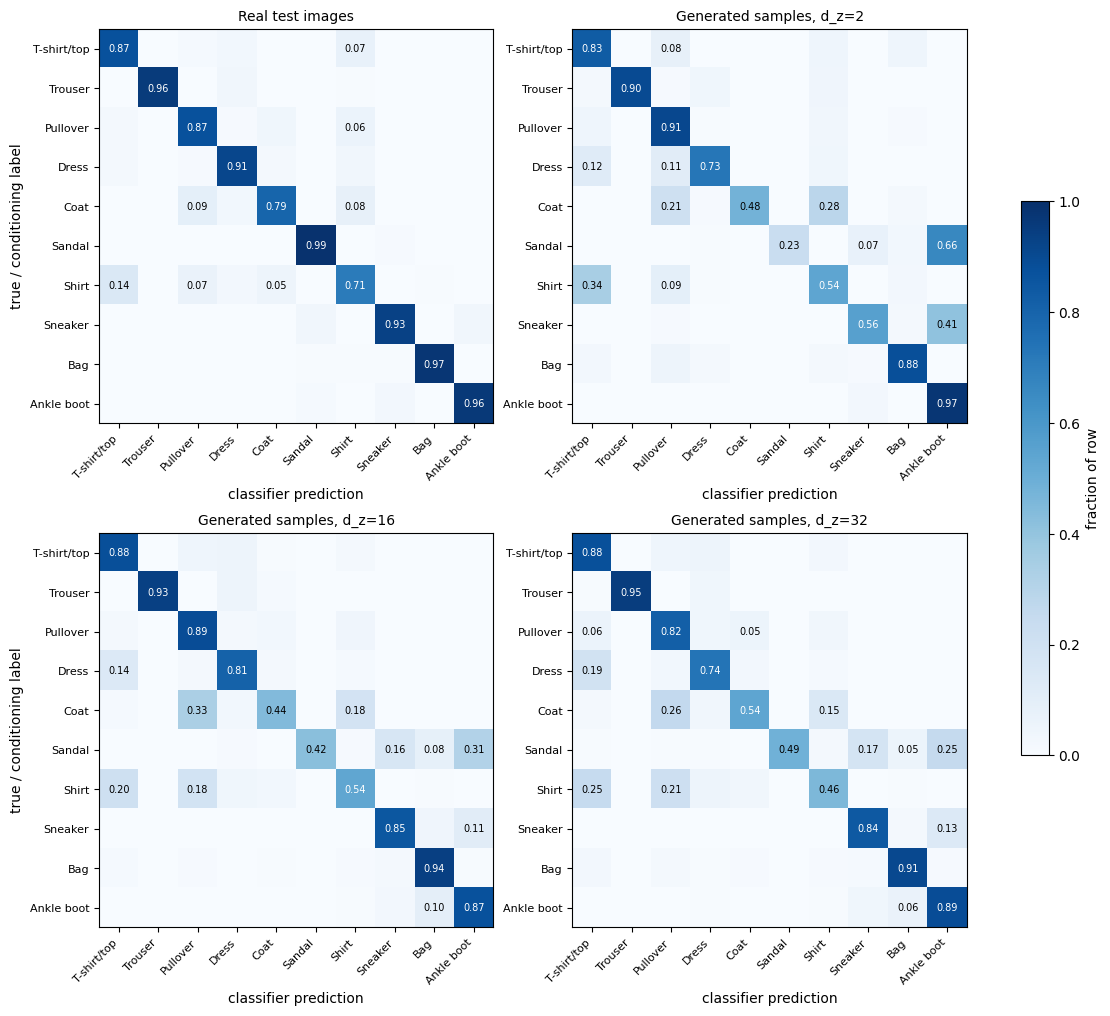

,real_recall,gen_acc_z2,top_confusion_z2,gen_acc_z16,top_confusion_z16,gen_acc_z32,top_confusion_z32
T-shirt/top,0.874,0.829,Pullover (0.08),0.879,Dress (0.05),0.878,Dress (0.05)
Trouser,0.956,0.895,Shirt (0.04),0.934,Dress (0.05),0.948,Dress (0.04)
Pullover,0.872,0.909,T-shirt/top (0.05),0.888,Shirt (0.04),0.819,T-shirt/top (0.06)
Dress,0.912,0.730,T-shirt/top (0.12),0.805,T-shirt/top (0.14),0.736,T-shirt/top (0.19)
Coat,0.793,0.479,Shirt (0.28),0.442,Pullover (0.33),0.537,Pullover (0.26)
Sandal,0.989,0.231,Ankle boot (0.66),0.424,Ankle boot (0.31),0.488,Ankle boot (0.25)
Shirt,0.709,0.539,T-shirt/top (0.34),0.535,T-shirt/top (0.20),0.455,T-shirt/top (0.25)
Sneaker,0.933,0.561,Ankle boot (0.41),0.850,Ankle boot (0.11),0.842,Ankle boot (0.13)
Bag,0.975,0.882,Pullover (0.05),0.940,Sneaker (0.02),0.905,T-shirt/top (0.03)
Ankle boot,0.962,0.973,Sneaker (0.03),0.872,Bag (0.10),0.887,Bag (0.06)


In [16]:
@torch.no_grad()
def predict_real(loader):
    # Classifier predictions on real images: returns (true labels, predictions).
    ys, ps = [], []
    for x, y in loader:
        ps.append(clf(x.to(device)).argmax(1).cpu())
        ys.append(y)
    return torch.cat(ys).numpy(), torch.cat(ps).numpy()


@torch.no_grad()
def predict_generated(model, per_class):
    # Same seed, label order and batching as label_consistency() in 6.5,
    # so these are the same samples that produced the 6.5 table.
    set_seed(SEED)
    labels = torch.arange(10).repeat_interleave(per_class).to(device)
    preds = torch.cat([clf(model.sample(lb)).argmax(1) for lb in labels.split(1000)])
    return labels.cpu().numpy(), preds.cpu().numpy()


def confusion(y_true, y_pred, k=10):
    # Row-normalised confusion matrix: entry (i, j) = P(prediction = j | label = i).
    cm = np.zeros((k, k))
    np.add.at(cm, (y_true, y_pred), 1)
    return cm / cm.sum(axis=1, keepdims=True)


y_real, p_real = predict_real(test_loader)
cms = {"Real test images": confusion(y_real, p_real)}
for d, m in models.items():
    yt, yp = predict_generated(m, CONFIG["gen_per_class"])
    cms[f"Generated samples, d_z={d}"] = confusion(yt, yp)
    # Consistency check against Section 6.5
    print(f"d_z={d:2d}: label consistency recomputed = {np.mean(yt == yp):.4f} "
          f"(Section 6.5: {rows[f'd_z={d}']['label_consistency_acc']:.4f})")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for k, (ax, (name, cm)) in enumerate(zip(axes.flat, cms.items())):
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    for i in range(10):
        for j in range(10):
            if cm[i, j] >= 0.05:                     # annotate only non-trivial cells
                ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=7,
                        color="white" if cm[i, j] > 0.5 else "black")
    ax.set_xticks(range(10)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(10)); ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_xlabel("classifier prediction")
    if k % 2 == 0:                                   # y-axis label on the left column only
        ax.set_ylabel("true / conditioning label")
    ax.set_title(name, fontsize=10)
fig.colorbar(im, ax=axes, shrink=0.6, label="fraction of row")
save_fig("confusion_matrices.png"); plt.show()

# Per-class summary: real recall, generated consistency, and the most frequent wrong prediction
summary = {"real_recall": np.diag(cms["Real test images"])}
for d in models:
    cm = cms[f"Generated samples, d_z={d}"]
    off = cm.copy(); np.fill_diagonal(off, 0)
    summary[f"gen_acc_z{d}"] = np.diag(cm)
    summary[f"top_confusion_z{d}"] = [f"{CLASS_NAMES[j]} ({off[i, j]:.2f})" for i, j in enumerate(off.argmax(1))]
conf_table = pd.DataFrame(summary, index=CLASS_NAMES)
conf_table.to_csv(os.path.join(CONFIG["results_dir"], "confusion_summary.csv"))
display(conf_table.round(3))

### 6.7 How much class information is stored in $z$? A latent probe

Section 8 asks whether the latent code of the CVAE stores class identity even though the label is already given to the decoder. Nothing in the conditional ELBO forces $z$ to be independent of $y$, so this is an empirical question. We test it with **probe classifiers** (Alain & Bengio, 2017): we encode images to their posterior means $\mu = \mathbb{E}_{q(z\mid x,y)}[z]$ and train a classifier to predict $y$ from $\mu$ alone.

* **Linear probe:** multinomial logistic regression on standardised $\mu$.
* **Non-linear probe:** $k$-nearest neighbours ($k=15$) on standardised $\mu$, which can detect class information that is not linearly separable.

The probes are fitted on 10,000 un-augmented training images and evaluated on the 10,000 test images. The chance level is 0.10 because the classes are balanced. A probe accuracy close to 0.10 means $z$ carries almost no class information (pure *style*); an accuracy close to the classifier ceiling means class identity is duplicated in $z$. Note that the probe can in principle score *above* the image classifier: the CVAE encoder receives $y$ as an input, so $\mu$ may carry the label directly instead of inferring it from pixels. Both probes use `scikit-learn` and are evaluation tools only.

In [17]:
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


@torch.no_grad()
def encode_dataset(model, dataset):
    # Posterior means mu for every image in `dataset` (encoded with its own label).
    loader = DataLoader(dataset, batch_size=1000, shuffle=False)
    mus, ys = [], []
    for x, y in loader:
        mus.append(model.encode_mean(x.to(device), y.to(device)).cpu())
        ys.append(y)
    return torch.cat(mus).numpy().astype(np.float64), torch.cat(ys).numpy()


probe_train_set = Subset(train_full_plain, train_idx[:10000])   # un-augmented training images

probe_rows = {}
for d, m in models.items():
    m.eval()
    mu_tr, y_tr = encode_dataset(m, probe_train_set)
    mu_te, y_te = encode_dataset(m, test_set)
    with warnings.catch_warnings():
        # As with t-SNE (7.6), plain matrix products emitted floating-point RuntimeWarnings on the
        # machine used for this notebook; they are silenced for both fitting and prediction, and the fitted model is checked below.
        warnings.simplefilter("ignore", RuntimeWarning)
        linear = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(mu_tr, y_tr)
        knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)).fit(mu_tr, y_tr)
        lin_pred, knn_pred = linear.predict(mu_te), knn.predict(mu_te)
    assert np.isfinite(linear[-1].coef_).all(), "linear probe has non-finite weights"
    probe_rows[f"d_z={d}"] = {"linear_probe_acc": float(np.mean(lin_pred == y_te)),
                              "knn_probe_acc": float(np.mean(knn_pred == y_te))}

probe = pd.DataFrame(probe_rows).T
probe["chance"] = 0.10
probe["classifier_on_real_images"] = real_acc
probe.to_csv(os.path.join(CONFIG["results_dir"], "latent_probe.csv"))
display(probe.round(3))

,linear_probe_acc,knn_probe_acc,chance,classifier_on_real_images
d_z=2,0.222,0.297,0.1,0.898
d_z=16,0.596,0.839,0.1,0.898
d_z=32,0.962,0.908,0.1,0.898


### 6.8 Summary of quantitative findings

All numbers below are taken from the outputs of Sections 6.2–6.7 in this notebook (single seed).

* **Reconstruction vs. KL trade-off.** From $d_z=2$ to $d_z=16$, the test reconstruction BCE falls from 247.66 to 225.59 nats (MSE per pixel 0.0244 → 0.0138) while the KL rises from 5.36 to 11.56 nats. From $d_z=16$ to $d_z=32$ the gain is much smaller: BCE 225.59 → 224.39 (MSE 0.0138 → 0.0131) for a KL increase of 0.53 nats. The negative ELBO follows the same pattern (253.02 → 237.14 → 236.48). This is the rate–distortion trade-off of the ELBO, with clearly diminishing returns beyond $d_z=16$.
* **Latent usage.** Both units are active for $d_z=2$, but only 7 of 16 and 8 of 32 are active for the larger models. Doubling the latent size from 16 to 32 therefore adds a single active unit; the KL penalty switches the other dimensions off (they collapse to the prior). This agrees with the small differences between $d_z=16$ and $d_z=32$ in every other metric.
* **Strength of the conditioning.** Label consistency is 0.703, 0.757 and 0.750 for $d_z = 2, 16, 32$, far above chance (0.10) and equal to about 78%, 84% and 84% of the classifier's accuracy on real test images (0.8975). The smallest latent space gives the weakest conditioning; the difference between $d_z=16$ and $d_z=32$ (0.007) is too small to interpret from a single seed.
* **Per-class behaviour.** *Sandal* is the least consistent class for every latent size (0.231, 0.424, 0.488), followed by *Coat* (0.479, 0.442, 0.537) and *Shirt* (0.539, 0.535, 0.455). *Trouser*, *Bag*, *T-shirt/top* and *Ankle boot* are at or above 0.829 for every latent size. The largest change with latent size is *Sneaker*, which rises from 0.561 at $d_z=2$ to 0.850 at $d_z=16$.
* **Confusions (6.6).** Generated *Sandal* samples are mostly classified as other footwear: 66% as *Ankle boot* for $d_z=2$, and 31% *Ankle boot* plus 16% *Sneaker* for $d_z=16$. The classifier recognises 98.9% of *real* sandals, so this failure lies in the generated samples, not in the classifier. The same footwear confusion explains the weak *Sneaker* score at $d_z=2$ (41% predicted as *Ankle boot*). The upper-body classes are confused with each other: *Coat* → *Pullover* (0.33 for $d_z=16$, 0.26 for $d_z=32$), *Shirt* → *T-shirt/top* (0.34, 0.20, 0.25) and *Dress* → *T-shirt/top* (0.12, 0.14, 0.19). Unlike Sandal, Shirt and Coat are also the hardest classes on real images (recall 0.709 and 0.793), so part of their low score reflects the classifier and the data; their generated scores are nevertheless clearly lower (0.535 and 0.442 for $d_z=16$). For *T-shirt/top* and *Pullover*, generated consistency matches or exceeds real recall (e.g. 0.879 vs. 0.874 for T-shirt/top at $d_z=16$).
* **Class information in $z$ (6.7).** The linear probe reaches 0.222, 0.596 and 0.962, and the kNN probe 0.297, 0.839 and 0.908, for $d_z = 2, 16, 32$ (chance 0.10). The posterior means of the $d_z=2$ model carry little class information, but this grows sharply with latent size; for $d_z=32$ the linear probe even exceeds the image classifier on real images (0.8975), which suggests that the encoder passes the label it is given into $\mu$. For $d_z=16$ the kNN probe is much stronger than the linear one (0.839 vs. 0.596), so the class information there is present but not linearly separable. Importantly, the large increase in probe accuracy from $d_z=16$ to $d_z=32$ comes with no change in label consistency (0.757 vs. 0.750).
* **Training length.** The best validation epoch was 30, 30 and 29 for $d_z = 2, 16, 32$, and the curves in 6.3 are still decreasing, so all three models are slightly under-trained. The comparisons above should be read as comparisons at an equal training budget.

## 7. Analysis and Qualitative Visualisation

*This section contains only qualitative outputs. Unless stated otherwise, the main model ($d_z=16$) is used.*

In [18]:
model = models[CONFIG["main_latent_dim"]].eval()

def show_grid(imgs, nrow, title, fname, figsize=(9, 9), ylabels=None, xlabels=None):
    # imgs: (N, 1, 28, 28) tensor in [0,1]
    grid = make_grid(imgs.cpu(), nrow=nrow, padding=2, pad_value=1.0)
    plt.figure(figsize=figsize)
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.title(title)
    ax = plt.gca()
    step = 28 + 2
    if ylabels is not None:
        ax.set_yticks([2 + step * i + 14 for i in range(len(ylabels))]); ax.set_yticklabels(ylabels, fontsize=8)
    else:
        ax.set_yticks([])
    if xlabels is not None:
        ax.set_xticks([2 + step * i + 14 for i in range(len(xlabels))])
        ax.set_xticklabels(xlabels, fontsize=8, rotation=45, ha="right")
    else:
        ax.set_xticks([])
    for s in ax.spines.values(): s.set_visible(False)
    save_fig(fname); plt.show()

### 7.1 Samples from the prior (class-conditional)

Each row uses one class label $y$. Each column is an independent draw $z \sim \mathcal{N}(0, I)$. The images shown are the Bernoulli means $\hat{x} = \mathrm{sigmoid}(\text{logits})$, which is the usual way to display VAE samples. The grid is rendered at high resolution and saved to `results/`.

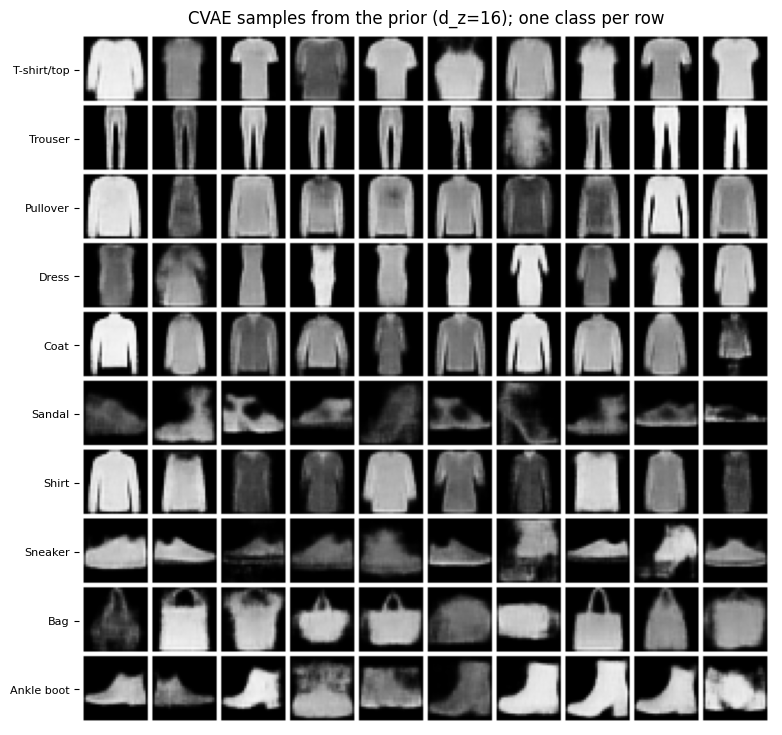

In [19]:
set_seed(SEED)
labels = torch.arange(10, device=device).repeat_interleave(10)
samples = model.sample(labels)
show_grid(samples, nrow=10, title=f"CVAE samples from the prior (d_z={CONFIG['main_latent_dim']}); one class per row",
          fname="samples_prior_grid.png", ylabels=CLASS_NAMES)

### 7.2 Test-set reconstructions

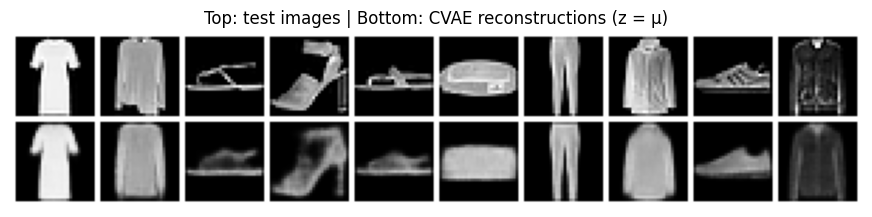

In [20]:
x_test, y_test = next(iter(DataLoader(test_set, batch_size=10, shuffle=True, generator=torch.Generator().manual_seed(1))))
x_test, y_test = x_test.to(device), y_test.to(device)
recon = model.sample(y_test, z=model.encode_mean(x_test, y_test))
show_grid(torch.cat([x_test, recon]), nrow=10, title="Top: test images | Bottom: CVAE reconstructions (z = μ)",
          fname="reconstructions.png", figsize=(11, 2.8))

### 7.3 Latent interpolation within a class

We encode two test images of the same class to their posterior means $\mu_A$ and $\mu_B$, then decode points on the line $z(t) = (1-t)\,\mu_A + t\,\mu_B$ with the label fixed. A smooth sequence of plausible images indicates a continuous, well-organised latent space.

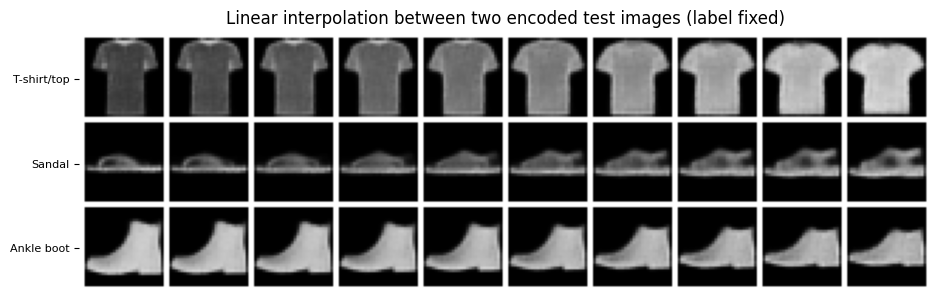

In [21]:
rows_img = []
interp_classes = [0, 5, 9]         # T-shirt/top, Sandal, Ankle boot
ts = torch.linspace(0, 1, 10, device=device)
for c in interp_classes:
    idx = (test_set.targets == c).nonzero().flatten()[[3, 40]]
    xa, xb = test_set[idx[0]][0].unsqueeze(0).to(device), test_set[idx[1]][0].unsqueeze(0).to(device)
    lab = torch.tensor([c], device=device)
    za, zb = model.encode_mean(xa, lab), model.encode_mean(xb, lab)
    zs = torch.stack([(1 - t) * za[0] + t * zb[0] for t in ts])
    rows_img.append(model.sample(lab.repeat(10), z=zs))
show_grid(torch.cat(rows_img), nrow=10, title="Linear interpolation between two encoded test images (label fixed)",
          fname="interpolation.png", figsize=(11, 3.6), ylabels=[CLASS_NAMES[c] for c in interp_classes])

### 7.4 Style transfer: fixed $z$, varying label

This visualisation is specific to the CVAE. We encode a real test image (left column) to $\mu$, keep that code fixed, and decode it with each of the 10 labels. If the latent space encodes *style* independently of *class*, each row should show the same style attributes (e.g. brightness, width, thickness) rendered as different garments.

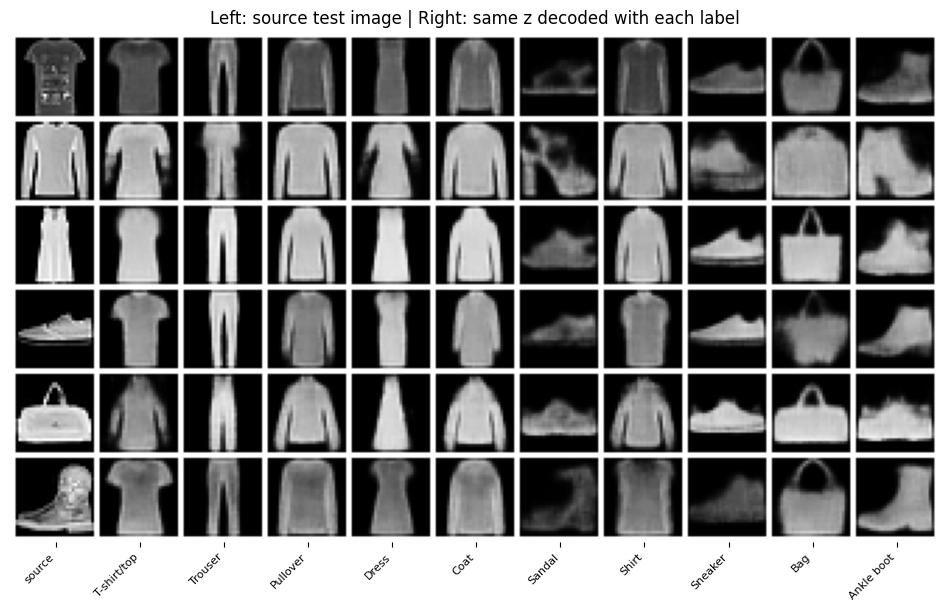

In [22]:
src_idx = [(test_set.targets == c).nonzero().flatten()[7].item() for c in [0, 2, 3, 7, 8, 9]]
rows_img = []
for i in src_idx:
    x, y = test_set[i]
    x = x.unsqueeze(0).to(device)
    mu = model.encode_mean(x, torch.tensor([y], device=device))
    decoded = model.sample(torch.arange(10, device=device), z=mu.repeat(10, 1))
    rows_img.append(torch.cat([x, decoded]))
show_grid(torch.cat(rows_img), nrow=11, title="Left: source test image | Right: same z decoded with each label",
          fname="style_transfer.png", figsize=(12, 7.5),
          xlabels=["source"] + CLASS_NAMES)

### 7.5 Two-dimensional latent space ($d_z = 2$)

With $d_z=2$, the latent space can be shown directly, without any projection:

* **(a)** the posterior means $\mu$ of 5,000 test images, coloured by class;
* **(b)** a *latent manifold*: a regular grid of $z$ values, mapped through the inverse Gaussian CDF so that it covers the prior evenly, decoded with a fixed label.

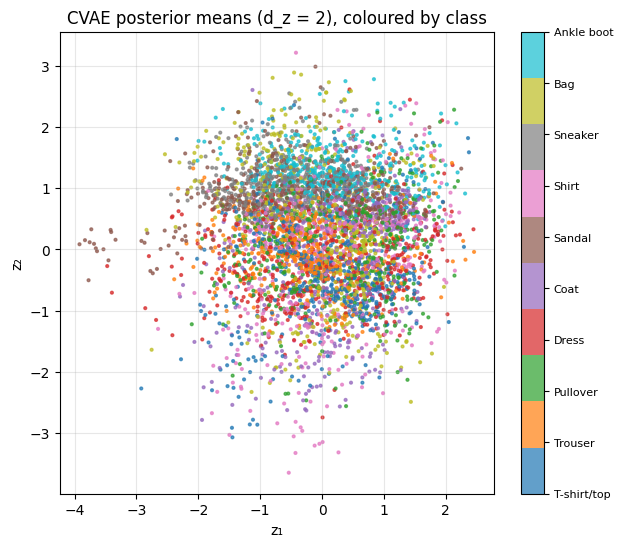

In [23]:
m2 = models[2].eval()
sub = DataLoader(Subset(test_set, range(5000)), batch_size=1000)
mus, labs = [], []
for x, y in sub:
    mus.append(m2.encode_mean(x.to(device), y.to(device)).cpu()); labs.append(y)
mus, labs = torch.cat(mus).numpy(), torch.cat(labs).numpy()

plt.figure(figsize=(7, 6))
sc = plt.scatter(mus[:, 0], mus[:, 1], c=labs, cmap="tab10", s=4, alpha=0.7)
cb = plt.colorbar(sc, ticks=range(10)); cb.ax.set_yticklabels(CLASS_NAMES, fontsize=8)
plt.xlabel("z₁"); plt.ylabel("z₂"); plt.title("CVAE posterior means (d_z = 2), coloured by class")
plt.grid(alpha=.3); save_fig("latent2d_scatter.png"); plt.show()

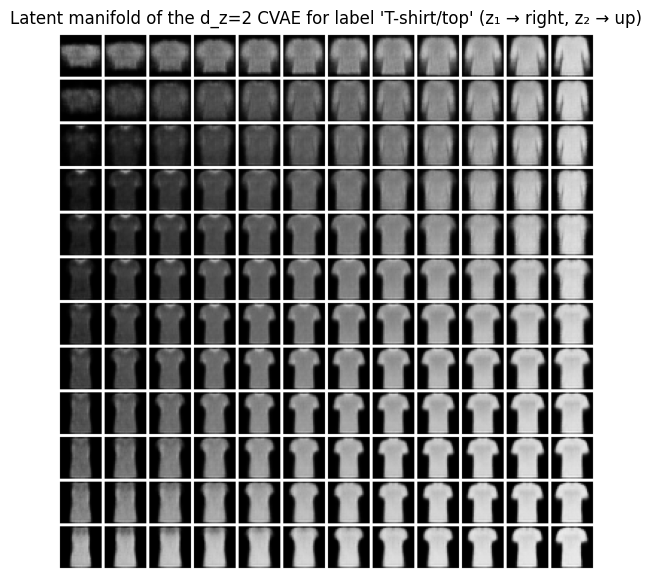

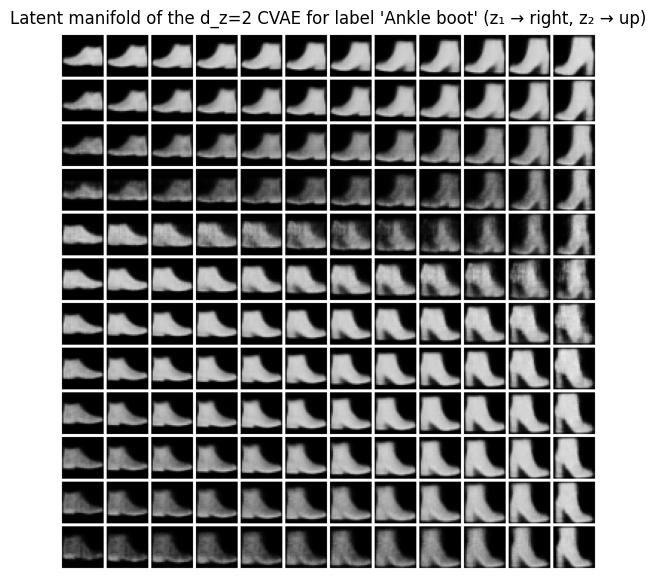

In [24]:
n = 12
normal = torch.distributions.Normal(0.0, 1.0)
grid_vals = normal.icdf(torch.linspace(0.05, 0.95, n))
zz = torch.stack(torch.meshgrid(grid_vals, grid_vals.flip(0), indexing="xy"), dim=-1).reshape(-1, 2).to(device)
for c in [0, 9]:
    imgs = m2.sample(torch.full((n * n,), c, device=device), z=zz)
    show_grid(imgs, nrow=n, title=f"Latent manifold of the d_z=2 CVAE for label '{CLASS_NAMES[c]}' "
              f"(z₁ → right, z₂ → up)", fname=f"latent2d_manifold_class{c}.png", figsize=(7, 7))

### 7.6 t-SNE of the $d_z=16$ latent space

To inspect the higher-dimensional latent space, we project the posterior means of 3,000 test images to 2-D with t-SNE (van der Maaten & Hinton, 2008), using `scikit-learn`'s implementation as an external visualisation library.

Only the **active** latent dimensions (same criterion as Section 6.4) are used. The inactive dimensions have almost zero variance across images, so they barely affect the distances t-SNE works with, and removing them keeps the input well conditioned. The embedding is checked explicitly for non-finite values.

t-SNE preserves local neighbourhoods but not global distances, so cluster sizes and the gaps between clusters should not be over-interpreted.

t-SNE input: 7 active of 16 latent dimensions


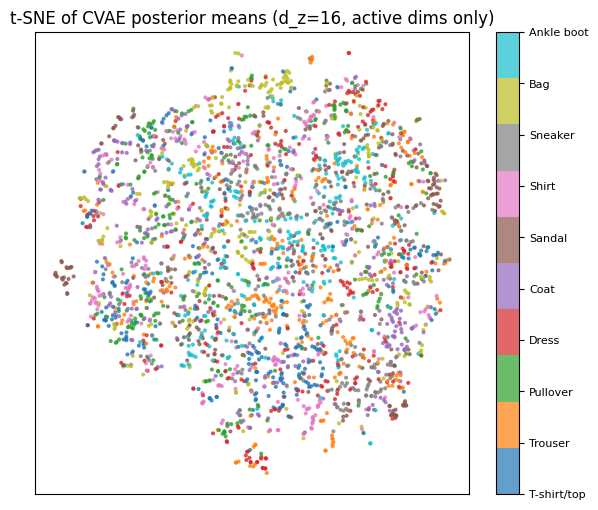

In [25]:
import warnings
from sklearn.manifold import TSNE

sub = DataLoader(Subset(test_set, range(3000)), batch_size=1000)
mus16, labs16 = [], []
for x, y in sub:
    mus16.append(model.encode_mean(x.to(device), y.to(device)).cpu()); labs16.append(y)
mus16, labs16 = torch.cat(mus16).numpy().astype(np.float64), torch.cat(labs16).numpy()

active_dims = mus16.var(axis=0) > 0.01          # same active-unit criterion as Section 6.4
feats = mus16[:, active_dims]
print(f"t-SNE input: {active_dims.sum()} active of {mus16.shape[1]} latent dimensions")

with warnings.catch_warnings():
    # The PCA initialisation emitted floating-point RuntimeWarnings in an earlier run of this
    # notebook; they are silenced here and the result is verified with the assert below.
    warnings.simplefilter("ignore", RuntimeWarning)
    emb = TSNE(n_components=2, perplexity=30, init="pca", random_state=SEED).fit_transform(feats)
assert np.isfinite(emb).all(), "t-SNE embedding contains non-finite values"

plt.figure(figsize=(7, 6))
sc = plt.scatter(emb[:, 0], emb[:, 1], c=labs16, cmap="tab10", s=4, alpha=0.7)
cb = plt.colorbar(sc, ticks=range(10)); cb.ax.set_yticklabels(CLASS_NAMES, fontsize=8)
plt.title(f"t-SNE of CVAE posterior means (d_z={CONFIG['main_latent_dim']}, active dims only)")
plt.xticks([]); plt.yticks([])
save_fig("latent_tsne.png"); plt.show()

### 7.7 Samples across latent sizes

The same labels and the same noise seed are used for each model, so the rows can be compared directly.

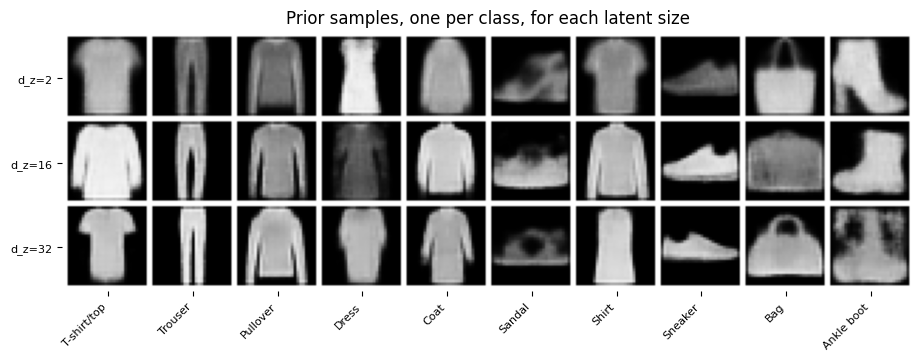

In [26]:
rows_img = []
for d, m in models.items():
    set_seed(SEED)
    rows_img.append(m.eval().sample(torch.arange(10, device=device)))
show_grid(torch.cat(rows_img), nrow=10, title="Prior samples, one per class, for each latent size",
          fname="samples_by_latent_dim.png", figsize=(11, 3.6),
          ylabels=[f"d_z={d}" for d in models], xlabels=CLASS_NAMES)

## 8. Qualitative Discussion

**Blurriness.** Samples and reconstructions are recognisable but smooth, and fine detail is largely lost. The reconstructions in 7.2 show this directly: the thin straps of the sandals are filled in, so the reconstructed sandals look like low, closed shoes; the stripes on the sneaker and the texture of the coat disappear. This is the well-known blurriness of VAEs. With a factorised pixel likelihood (Bernoulli here), the decoder is rewarded for predicting the *average* of all images consistent with $z$ and $y$, and when the latent code does not pin down high-frequency detail, that average is smooth. Prior samples (7.1) are more variable than reconstructions: most are plausible, but some are clearly malformed (for example the blob in the *Trouser* row and several patchy *Ankle boot* samples), which does not happen in the reconstructions, because a posterior mean $\mu$ carries far more information about a specific image than a random draw from $\mathcal{N}(0, I)$.

**Variant-specific improvement: label control.** The class-per-row grid (7.1) shows that the label steers *which* garment is produced, which a standard VAE cannot do without searching the latent space. The style-transfer grid (7.4) shows the same control from a different angle: for every source image, each label column is decoded as an item of that type. At the same time, the latent code carries *style* across labels: the dark, printed T-shirt produces mostly dark-grey items across the columns, while bright source images produce bright items. Some shape information also carries over: the wide bag's code, decoded as *Dress* or *Ankle boot*, gives a wide, low silhouette. The *Sandal* column is the weakest: several of its images look like low closed shoes rather than strappy sandals, matching the low consistency of this class in 6.5.

**Why label consistency stays below the ceiling.** The quantitative results point to three factors, which are not mutually exclusive.

1. *Loss of class-defining detail.* Classes that are defined by fine structure suffer most from blurriness. Sandal, whose defining feature is its straps, is the least consistent class for every latent size (0.231–0.488), and the reconstructions in 7.2 show that the straps are lost even when the model sees the real image. The smallest model ($d_z=2$), which has the highest reconstruction error (MSE 0.0244 vs. 0.0138 for $d_z=16$), also has the lowest overall consistency (0.703 vs. 0.757), and its *Sneaker* consistency is much lower (0.561 vs. 0.850). This pattern is consistent with sample fidelity limiting consistency, although a single seed cannot establish causality. The confusion matrices (6.6) confirm this: generated Sandal samples are mostly classified as other footwear (66% *Ankle boot* for $d_z=2$; 31% *Ankle boot* and 16% *Sneaker* for $d_z=16$), although the classifier recognises 98.9% of real sandals. The problem therefore lies in the samples, not in the evaluation classifier: without its straps, a sandal is read as a closed shoe.
2. *Classes that are similar even in real data.* Shirt and Coat are also among the least consistent classes. These upper-body garments look alike at 28×28, so part of their low score reflects the classifier and the data rather than the generator. Shirt and Coat have the two lowest real-image recalls (0.709 and 0.793), and the classifier's main confusions on real images (Shirt → T-shirt/top 0.14, Coat → Pullover 0.09) point in the same direction as those on generated samples (Shirt → T-shirt/top 0.20, Coat → Pullover 0.33 for $d_z=16$). The generated scores are still clearly lower (0.535 vs. 0.709 and 0.442 vs. 0.793), so the generator adds errors of the *same kind* on top of the classifier's own difficulty, consistent with blurry samples that look like an "average top".
3. *Class information in $z$.* Nothing in the conditional ELBO forces $z$ to be independent of $y$: the encoder sees $x$ (and $y$ itself), so it may store class information in $z$. The latent probe (6.7) shows that it does, increasingly with latent size: the linear probe recovers the label with accuracy 0.222, 0.596 and 0.962 for $d_z = 2, 16, 32$. The latent plots agree with this. In the $d_z=2$ scatter (7.5a), where the probes are weakest, most classes overlap heavily, with only the footwear codes shifted upwards and a small group of *Sandal* codes on the far left. In the t-SNE plot of the $d_z=16$ model (7.6) there are no ten large clusters, but many small groups of a single colour; this local, non-linear structure matches the gap between the kNN and linear probes (0.839 vs. 0.596). However, the evidence does **not** support class information in $z$ as the main reason for the imperfect conditioning. From $d_z=16$ to $d_z=32$ the linear probe rises from 0.596 to 0.962 while label consistency stays the same (0.757 vs. 0.750), and the $d_z=2$ model, whose latent code carries the *least* class information, has the *lowest* consistency (0.703). The style-transfer grid (7.4) explains why: when $z$ and $y$ disagree, the decoder follows $y$. In these experiments, class information in $z$ therefore answers research question 3 (the latent space is not pure style), but its effect on class-controlled generation appears small compared with factors 1 and 2.

**Latent space organisation.** The 2-D manifolds (7.5b) show that the latent axes encode continuous within-class properties. For *T-shirt/top*, moving along $z_1$ changes brightness from dark to light, and moving along $z_2$ changes the silhouette, from wider, boxier tops in the upper rows to narrower shapes in the lower rows. For *Ankle boot*, the shaft and heel become more pronounced towards the right, but a horizontal band in the middle rows produces noisy, speckled boots, so not every region of the prior decodes to a clean image for every label. The within-class interpolations (7.3) change smoothly, for example from a dark to a light T-shirt, without implausible intermediate images, which indicates a continuous latent space within each class.

**Effect of latent size.** $d_z=2$ has the highest reconstruction error and the weakest conditioning. $d_z=16$ and $d_z=32$ are almost identical in every metric, and the active-unit counts (7/16 and 8/32) explain why: the extra dimensions of the larger model are mostly unused. The two larger models nevertheless use their latent space differently: the posterior means of $d_z=32$ are far more class-informative (linear probe 0.962 vs. 0.596), even though their generative metrics are almost the same. One prior sample per class (7.7) is too few to rank the models visually, so the comparison relies on the quantitative results in Section 6.

**Failure modes.** The main failure modes are (i) loss of thin structures such as sandal straps, which turns sandals into generic closed shoes, (ii) samples that look like a blend of similar upper-body classes (Coat read as Pullover, Shirt and Dress read as T-shirt/top in 6.6), and (iii) occasional malformed samples from the prior, such as the blob in the *Trouser* row of 7.1 and the noisy band in the *Ankle boot* manifold. A possible explanation for (iii), not tested here, is a mismatch between the prior $\mathcal{N}(0, I)$ and the region of latent space actually occupied by encoded images of that class; reducing this kind of prior/aggregate-posterior mismatch is the motivation for InfoVAE (Zhao, Song & Ermon, 2019).

**Speed.** Generation needs a single decoder pass per image, so producing thousands of samples takes seconds. This is a practical advantage over autoregressive models (one pass per pixel) and iterative diffusion samplers.

## 9. Conclusion

**Summary.** I implemented a Conditional VAE from scratch in PyTorch: a label-conditioned convolutional encoder, the reparameterisation trick, a label-conditioned transposed-convolutional decoder, and the exact negative conditional ELBO with correctly scaled Bernoulli reconstruction and closed-form KL terms. The model was trained on Fashion-MNIST with a label-preserving augmentation, a held-out validation split and checkpoint selection. It was evaluated with isolated reconstruction/KL curves, test-set reconstruction metrics, active-unit counts and a label-consistency accuracy.

**Findings.** (i) Conditioning on the label gives clear but partial control over the generated class: label consistency reaches 0.757 for $d_z=16$, about 84% of the classifier's accuracy on real images, and the weakest classes are Sandal, Coat and Shirt. Sandal samples fail because they are read as other footwear, while Coat and Shirt are confused with neighbouring upper-body classes that are also hard to separate in real images. (ii) Larger latent spaces trade a higher KL for lower reconstruction error, with strongly diminishing returns beyond $d_z=16$, where only 7 of 16 (and 8 of 32) latent units are active. (iii) The smallest latent space gives both the worst reconstructions and the weakest conditioning, which is consistent with sample fidelity limiting how recognisable the generated classes are. (iv) The latent space encodes within-class style such as brightness and silhouette, but it is not class-free: a linear probe recovers the label from $\mu$ with accuracy 0.222, 0.596 and 0.962 for $d_z = 2, 16, 32$. This class information does not appear to weaken the conditioning, because label consistency is unchanged between $d_z=16$ and $d_z=32$ and the decoder follows $y$ when $z$ and $y$ disagree.

**Limitations.**

* The Bernoulli likelihood on grey-level pixels is not a normalised density (Section 4), so the ELBO values are not exact log-likelihoods.
* Samples are blurry, as is typical for VAEs with factorised pixel likelihoods.
* The label-consistency metric depends on the evaluation classifier (0.8975 accuracy on real test images).
* The models are slightly under-trained: validation loss was still decreasing at epoch 30.
* A single seed was used, so no confidence intervals are reported, and small differences (e.g. between $d_z=16$ and $d_z=32$) should not be over-interpreted.
* The explanations in Section 8 are supported by correlations across three models and by visual inspection, not by controlled ablations.

**Future work.**

* Replace the Bernoulli decoder with a continuous-Bernoulli or discretised likelihood.
* Reduce the prior/aggregate-posterior mismatch with an MMD regulariser, as in InfoVAE.
* Strengthen the use of $y$, for example by feeding the label into every decoder layer, and measure the effect on label consistency and on the latent probe.
* Report results over several seeds and train until the validation loss plateaus.

## References

* Alain, G., & Bengio, Y. (2017). Understanding intermediate layers using linear classifier probes. *ICLR Workshop*.
* Burda, Y., Grosse, R., & Salakhutdinov, R. (2016). Importance weighted autoencoders. *ICLR*.
* Kim, H., & Mnih, A. (2018). Disentangling by factorising. *ICML*.
* Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. *ICLR*.
* Kingma, D. P., & Welling, M. (2014). Auto-encoding variational Bayes. *ICLR*.
* Loaiza-Ganem, G., & Cunningham, J. P. (2019). The continuous Bernoulli: Fixing a pervasive error in variational autoencoders. *NeurIPS*.
* Sohn, K., Lee, H., & Yan, X. (2015). Learning structured output representation using deep conditional generative models. *NeurIPS*.
* van der Maaten, L., & Hinton, G. (2008). Visualizing data using t-SNE. *Journal of Machine Learning Research, 9*, 2579–2605.
* Xiao, H., Rasul, K., & Vollgraf, R. (2017). Fashion-MNIST: A novel image dataset for benchmarking machine learning algorithms. *arXiv:1708.07747*.
* Zhao, S., Song, J., & Ermon, S. (2019). InfoVAE: Balancing learning and inference in variational autoencoders. *AAAI*.

External libraries: PyTorch and torchvision (models, data loading, transforms), scikit-learn (t-SNE and the probe classifiers in 6.7, evaluation/visualisation only), matplotlib, NumPy and pandas.

## Appendix: Reproducibility summary

| Item | Value |
|---|---|
| Seed | 42 (Python, NumPy, PyTorch; seeded data split and shuffling) |
| Split | 55,000 train / 5,000 validation / 10,000 test |
| Preprocessing | `ToTensor()` → $[0,1]$; `RandomHorizontalFlip(0.5)` on train only |
| Architecture | 2× Conv(4, s2) encoder, 256-unit hidden layer, 2× ConvT(4, s2) decoder; one-hot label concatenated in encoder and decoder |
| Objective | Negative conditional ELBO: BCE (sum over pixels) + analytic KL (sum over latent dims), mean over batch |
| Optimiser | Adam, lr = 1e-3, batch size 128 |
| Epochs | 30 per latent size; best-validation checkpoint kept |
| Latent sizes | 2, 16 (main), 32 |
| Outputs | `checkpoints/` (weights + histories), `results/` (figures, CSV tables) |

*Note on shuffling.* `set_seed` is called at the start of each training run, but the three runs share one `DataLoader` generator, so each latent size sees a different (still deterministic) shuffle order. Results on MPS/CUDA may also differ slightly between machines.
